You can access from https://www.kaggle.com/uciml/german-credit

The original dataset contains 1000 entries with 20 categorial/symbolic attributes prepared by Prof. Hofmann. In this dataset, each entry represents a person who takes a credit by a bank. Each person is classified as good or bad credit risks according to the set of attributes. The link to the original dataset can be found below.

Content
It is almost impossible to understand the original dataset due to its complicated system of categories and symbols. Thus, I wrote a small Python script to convert it into a readable CSV file. Several columns are simply ignored, because in my opinion either they are not important or their descriptions are obscure. The selected attributes are:

Age (numeric)

Sex (text: male, female)

Job (numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)

Housing (text: own, rent, or free)

Saving accounts (text - little, moderate, quite rich, rich)

Checking account (numeric, in DM - Deutsch Mark)

Credit amount (numeric, in DM)

Duration (numeric, in month)

Purpose (text: car, furniture/equipment, radio/TV, domestic appliances, repairs, education, business, vacation/others)

In [47]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn import metrics

In [24]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Read the input file and check the data dimension

In [25]:
df = pd.read_csv("german_credit.csv")
df.shape, df.columns

((1000, 21), Index(['default', 'account_check_status', 'duration_in_month',
        'credit_history', 'purpose', 'credit_amount', 'savings',
        'present_emp_since', 'installment_as_income_perc',
        'personal_status_sex', 'other_debtors', 'present_res_since', 'property',
        'age', 'other_installment_plans', 'housing', 'credits_this_bank', 'job',
        'people_under_maintenance', 'telephone', 'foreign_worker'],
       dtype='object'))

In [26]:
df.head(3)

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes


In [27]:
#Read input file and understand the data
# "default" is my dependent variable

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

In [29]:
df.describe()

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.300000,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,0.458487,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,0.000000,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,0.000000,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,0.000000,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,1.000000,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,1.000000,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X, X_ = train_test_split(df, test_size=0.50, random_state=0)
X.shape, X_.shape

((500, 21), (500, 21))

In [32]:
# Lets build a Ensemble model but need to modify the dataset first

### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

### Check for highly correlated variables but don't required any treatment for this use case

### Drop the original variables which are converted to dummy

Note: Im not using pd.get_dummies(X), i will do label encoder, so that less number of columns needs to be handled.
and most of the processing can be reduced.

In [33]:
#Check how many columns are of non-numeric type
X.select_dtypes(include='object')

,account_check_status,credit_history,purpose,savings,present_emp_since,personal_status_sex,other_debtors,property,other_installment_plans,housing,job,telephone,foreign_worker
631,< 0 DM,all credits at this bank paid back duly,radio/television,... < 100 DM,1 <= ... < 4 years,male : single,none,"if not A121/A122 : car or other, not in attrib...",bank,own,skilled employee / official,none,yes
185,no checking account,critical account/ other credits existing (not ...,domestic appliances,... < 100 DM,1 <= ... < 4 years,male : single,none,if not A121 : building society savings agreeme...,none,own,skilled employee / official,none,yes
732,0 <= ... < 200 DM,existing credits paid back duly till now,domestic appliances,... < 100 DM,4 <= ... < 7 years,female : divorced/separated/married,guarantor,real estate,none,own,unskilled - resident,none,yes
404,0 <= ... < 200 DM,delay in paying off in the past,car (new),unknown/ no savings account,.. >= 7 years,male : single,none,"if not A121/A122 : car or other, not in attrib...",none,own,skilled employee / official,none,yes
194,0 <= ... < 200 DM,existing credits paid back duly till now,domestic appliances,100 <= ... < 500 DM,1 <= ... < 4 years,male : single,guarantor,if not A121 : building society savings agreeme...,none,rent,skilled employee / official,none,yes
564,0 <= ... < 200 DM,delay in paying off in the past,business,unknown/ no savings account,1 <= ... < 4 years,male : single,none,if not A121 : building society savings agreeme...,bank,own,management/ self-employed/ highly qualified em...,"yes, registered under the customers name",yes
401,0 <= ... < 200 DM,critical account/ other credits existing (not ...,business,unknown/ no savings account,1 <= ... < 4 years,male : married/widowed,none,real estate,bank,own,skilled employee / official,none,yes
530,0 <= ... < 200 DM,existing credits paid back duly till now,(vacation - does not exist?),... < 100 DM,4 <= ... < 7 years,male : single,none,"if not A121/A122 : car or other, not in attrib...",none,own,skilled employee / official,none,yes
656,0 <= ... < 200 DM,existing credits paid back duly till now,car (new),... < 100 DM,.. >= 7 years,male : single,none,"if not A121/A122 : car or other, not in attrib...",bank,own,unskilled - resident,none,yes
441,< 0 DM,existing credits paid back duly till now,radio/television,... < 100 DM,1 <= ... < 4 years,female : divorced/separated/married,co-applicant,if not A121 : building society savings agreeme...,none,own,skilled employee / official,none,yes


In [34]:
#Print all the column names
cols = list(X.select_dtypes(include='object').columns)
print(cols)

['account_check_status', 'credit_history', 'purpose', 'savings', 'present_emp_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


In [35]:
#Use label encoding to convert all the non integer objects and update the dataframe X
for col in cols:
    le = preprocessing.LabelEncoder()
    le.fit(X[col])
    X[col] = le.transform(X[col])
    print(col, dict(zip(le.classes_, le.transform(le.classes_))))

account_check_status {'0 <= ... < 200 DM': 0, '< 0 DM': 1, '>= 200 DM / salary assignments for at least 1 year': 2, 'no checking account': 3}
credit_history {'all credits at this bank paid back duly': 0, 'critical account/ other credits existing (not at this bank)': 1, 'delay in paying off in the past': 2, 'existing credits paid back duly till now': 3, 'no credits taken/ all credits paid back duly': 4}
purpose {'(vacation - does not exist?)': 0, 'business': 1, 'car (new)': 2, 'car (used)': 3, 'domestic appliances': 4, 'education': 5, 'furniture/equipment': 6, 'radio/television': 7, 'repairs': 8, 'retraining': 9}
savings {'.. >= 1000 DM ': 0, '... < 100 DM': 1, '100 <= ... < 500 DM': 2, '500 <= ... < 1000 DM ': 3, 'unknown/ no savings account': 4}
present_emp_since {'.. >= 7 years': 0, '... < 1 year ': 1, '1 <= ... < 4 years': 2, '4 <= ... < 7 years': 3, 'unemployed': 4}
personal_status_sex {'female : divorced/separated/married': 0, 'male : divorced/separated': 1, 'male : married/widowe

In [36]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 500 entries, 631 to 684
Data columns (total 21 columns):
default                       500 non-null int64
account_check_status          500 non-null int64
duration_in_month             500 non-null int64
credit_history                500 non-null int64
purpose                       500 non-null int64
credit_amount                 500 non-null int64
savings                       500 non-null int64
present_emp_since             500 non-null int64
installment_as_income_perc    500 non-null int64
personal_status_sex           500 non-null int64
other_debtors                 500 non-null int64
present_res_since             500 non-null int64
property                      500 non-null int64
age                           500 non-null int64
other_installment_plans       500 non-null int64
housing                       500 non-null int64
credits_this_bank             500 non-null int64
job                           500 non-null int64
people_unde

In [37]:
X.shape

(500, 21)

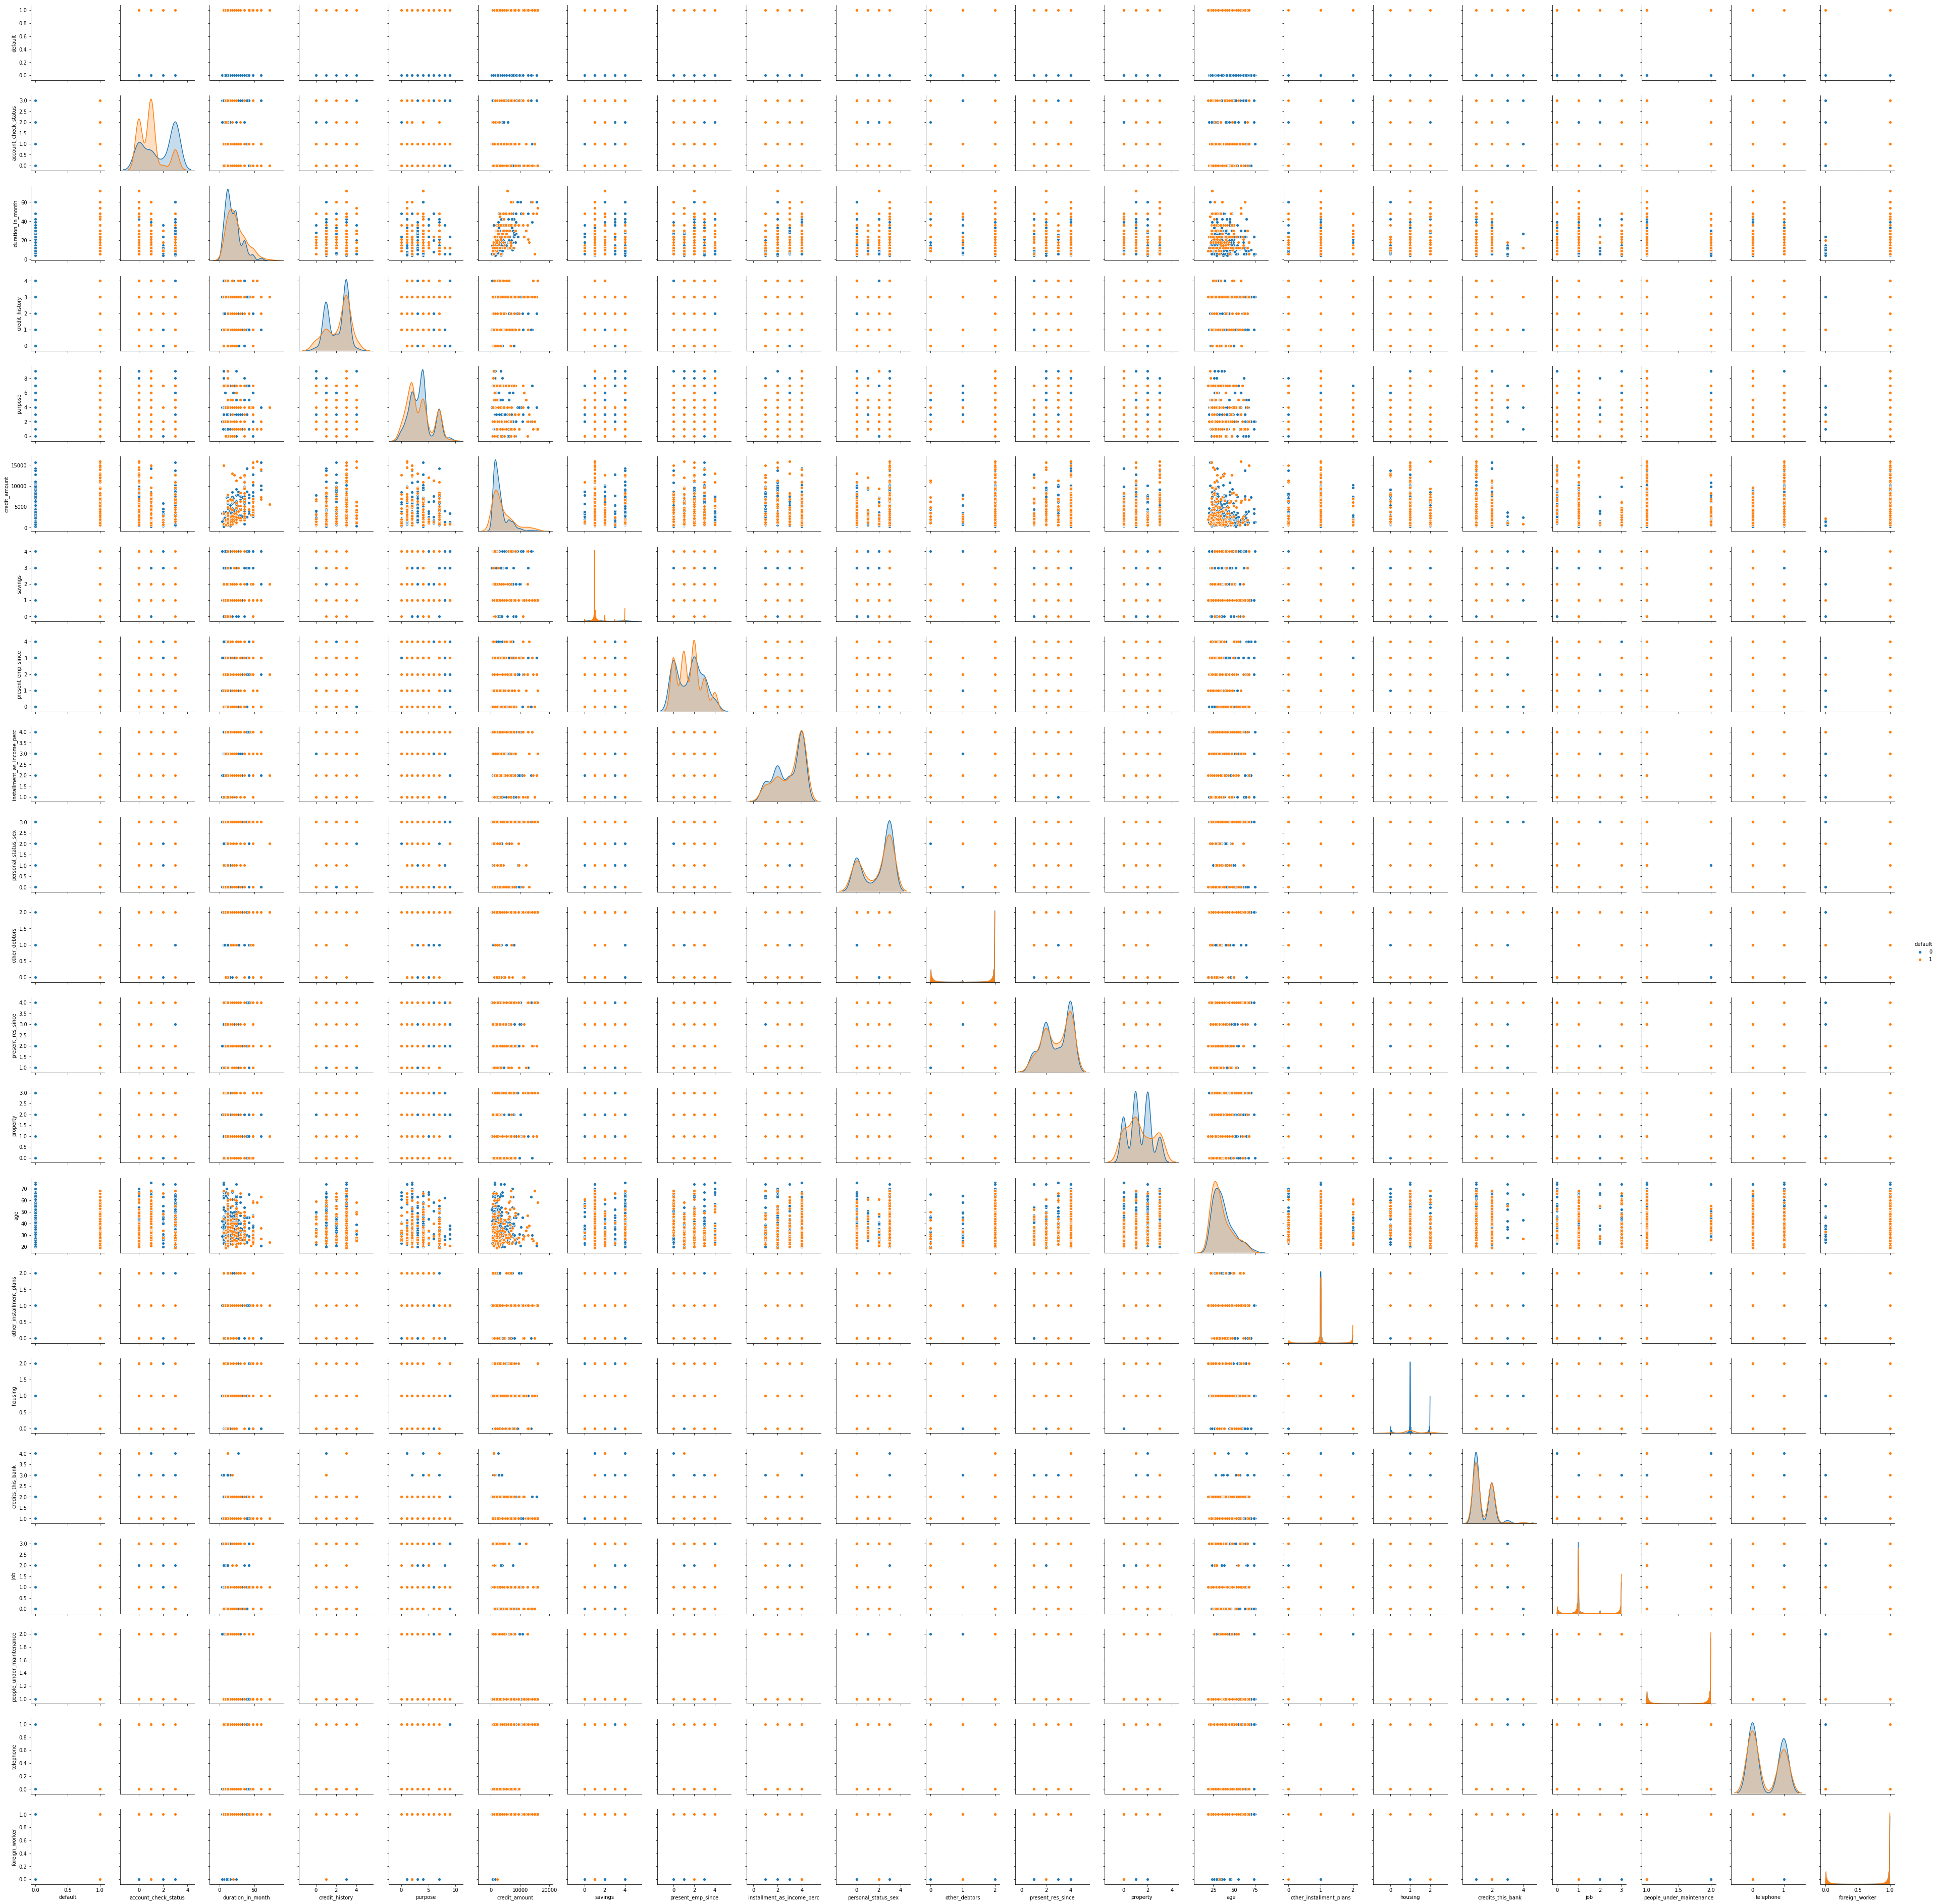

In [38]:
# Pairplot using sns
sns.pairplot(X, hue="default")

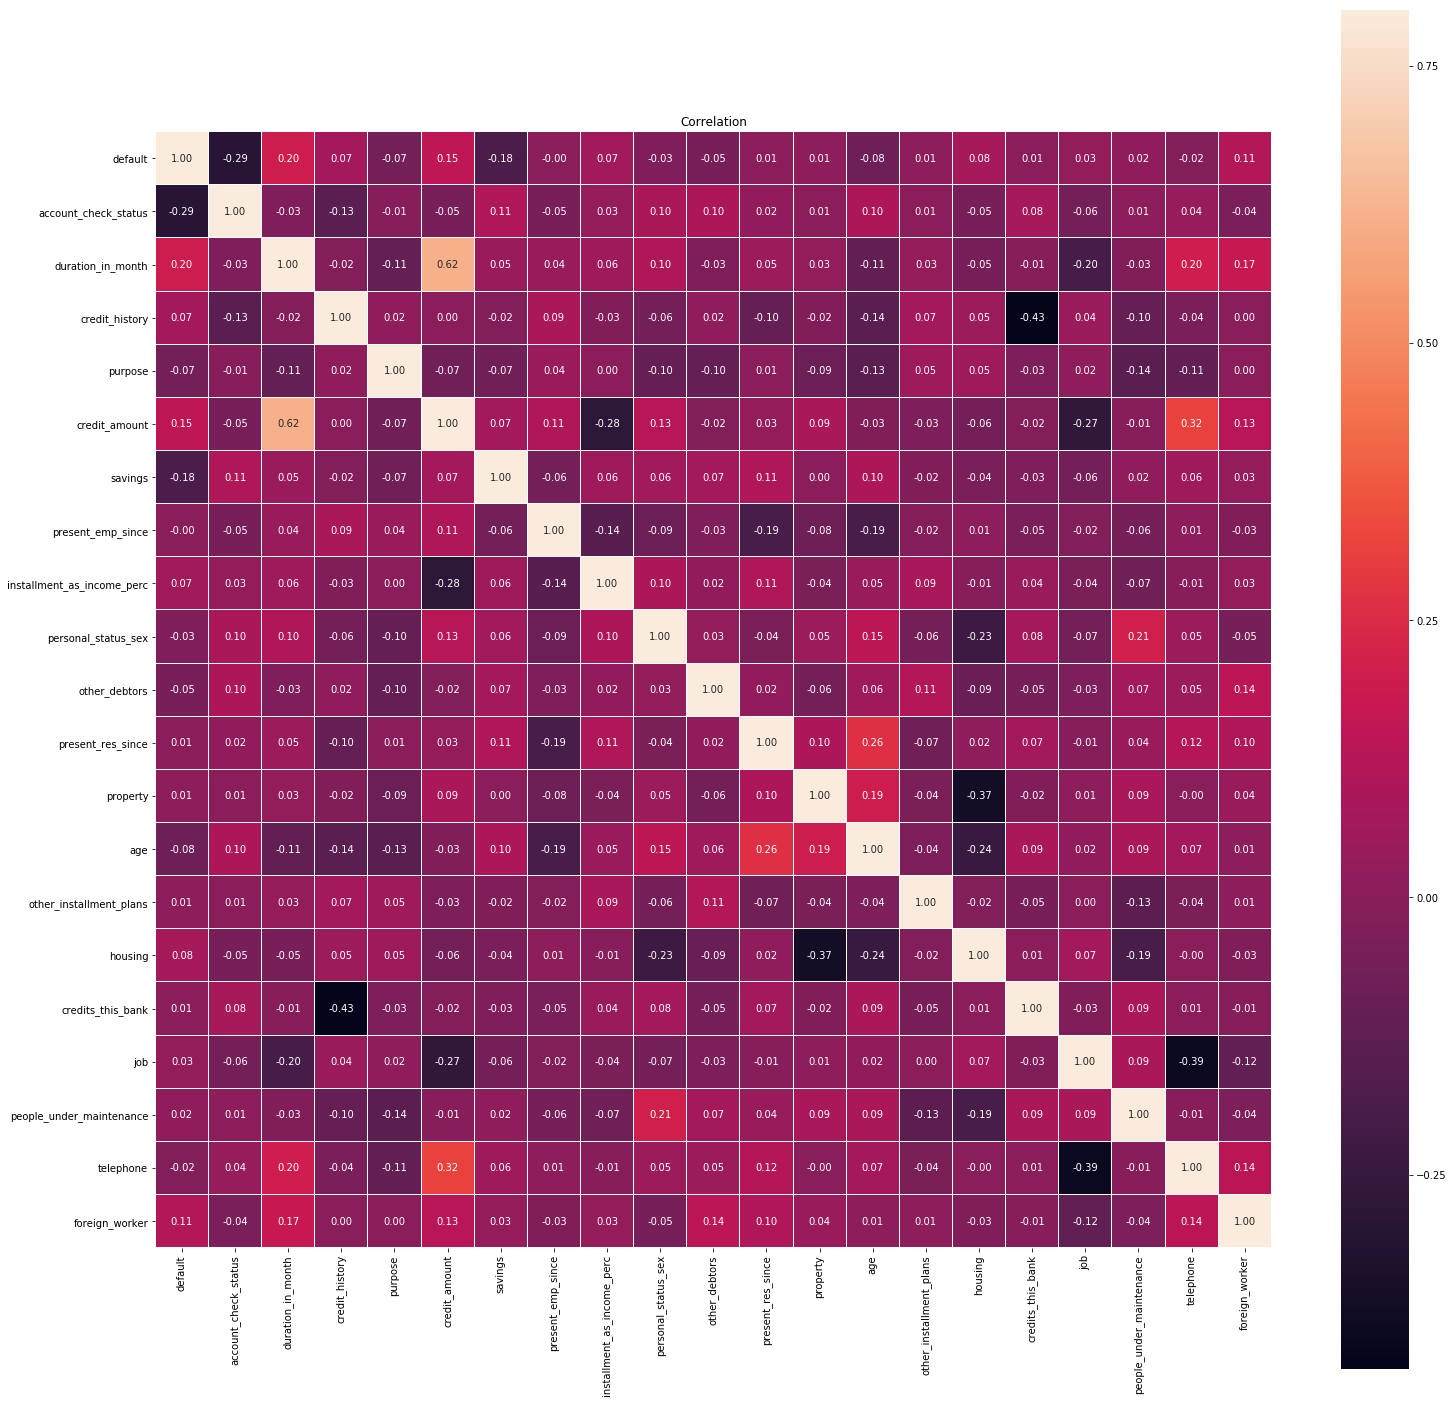

In [39]:
from matplotlib import pyplot as plt
plt.figure(figsize=(25, 25))
ax = sns.heatmap(X.corr(), vmax=.8, square=True, fmt='.2f', annot=True, linecolor='white', linewidths=0.01)
plt.title('Correlation')
plt.show()

#### Inference:
No need to remove any columns now as from the heat map, the corelation between columns are not high.

### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [40]:
X_in = X.drop(['default'], axis=1)
Y_in = X.pop("default")
X_in.shape, Y_in.shape 

((500, 20), (500,))

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(X_in, Y_in, test_size=0.30, random_state=0)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((350, 20), (150, 20), (350,), (150,))

### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
Rf_model = RandomForestClassifier(n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999)
Rf_model.fit(X_train, Y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

In [48]:
y_predict = Rf_model.predict(X_test)

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [49]:
rf_acc = metrics.accuracy_score(Y_test, y_predict)
rf_acc

0.7133333333333334

In [50]:
rf_cr = metrics.classification_report(Y_test , y_predict)
print(rf_cr)

              precision    recall  f1-score   support

           0       0.72      0.94      0.82       103
           1       0.62      0.21      0.32        47

   micro avg       0.71      0.71      0.71       150
   macro avg       0.67      0.58      0.57       150
weighted avg       0.69      0.71      0.66       150



In [51]:
rf_cm = metrics.confusion_matrix(Y_test , y_predict)
print(rf_cm)

[[97  6]
 [37 10]]


### Q6 Show the list of the features importance( 1 Marks)

In [54]:
for col, fi in zip(X_test.columns, Rf_model.feature_importances_):
    print (col, fi)

account_check_status 0.09549151584449869
duration_in_month 0.10660233020368058
credit_history 0.0676630277776384
purpose 0.061546760657
credit_amount 0.14158806191004863
savings 0.049857823483259456
present_emp_since 0.0488554910960899
installment_as_income_perc 0.04531761607310318
personal_status_sex 0.03269290227960891
other_debtors 0.013185789417225154
present_res_since 0.044540458936181096
property 0.047785372528230514
age 0.10084082170421568
other_installment_plans 0.02122838099201912
housing 0.027744664944408127
credits_this_bank 0.02237108194628966
job 0.035511541308383875
people_under_maintenance 0.012256377441092302
telephone 0.020682708571437544
foreign_worker 0.004237272885589234


Text(0.5, 0, 'Relative Importance')

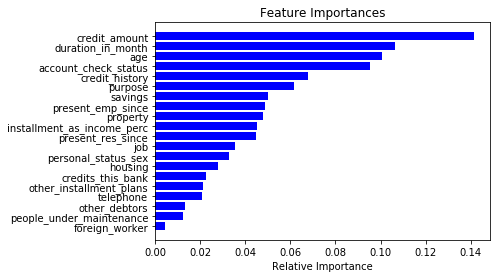

In [55]:
features = X_test.columns
importances = Rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(1)
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), features[indices])
plt.xlabel('Relative Importance')

### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [0]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [0]:
# Use below values
num_folds = 10
seed = 77

In [0]:
#Validate the Random Forest model build above using k fold

In [0]:
#Calculate Mean score

In [0]:
# Calculate score standard deviation using std()

# Q8 Print the confusion matrix( 1 Marks)

# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [0]:
#Hint: Use roc_curve

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [0]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [0]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    rfm.fit(X_, y_)
    y_pred = rfm.predict(X_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [0]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())

Accuracy Score
Avearge:  0.6893333333333334
Standard deviation:  0.014966629547095768
